# Day 19b (Extension): Network Visualization — Drawing & Inspecting a CNN's Architecture

> **Goal:** learn the *industry-standard toolchain* for visualizing a neural network's **structure** (topology), as a complement to **Day 19**, which visualizes its **behavior** (filters, feature maps, CAM).

## Two axes of "looking inside" a network

| Axis | Question it answers | Day | What you use |
|---|---|---|---|
| **Behavior** | *What did the network learn?* | **Day 19** | filters, feature maps, CAM, activation stats, dead ReLUs |
| **Structure** | *What is the network, and how do the pieces connect?* | **Day 19b (this notebook)** | `torchinfo`, VisualTorch, Netron, TensorBoard, *(optional)* torchviz / torchview |

Day 19 turned the microscope on the **activations**; today we draw the **blueprint**.

This is an **extension notebook** (like `day17b` and `day21_extra`): it sits *beside* the main arc and reuses models you already built. Nothing here trains anything — we only need the *architecture*, so it runs fast and offline.


## Prerequisites & install

This notebook uses a few optional packages, deliberately kept out of the core `requirements.txt`:

```bash
.venv/bin/pip install -r requirements-viz.txt   # torchinfo, visualtorch, netron, onnx
```

- **Pure-pip and fully encapsulated** inside `.venv` — no system packages, nothing global.
- **Optional (needs the Graphviz `dot` binary):** `torchviz` and `torchview` for the autograd / module-hierarchy graphs.
  `brew install graphviz && .venv/bin/pip install graphviz torchviz torchview`
  The two cells that use them are **guarded** and skip gracefully if you don't have them.

Everything below runs even if you only did the first `pip install`.


In [1]:
# --- Core imports -------------------------------------------------------------------
import torch
import torch.nn as nn
from pathlib import Path
from IPython.display import display

# Tabular inspection (requirements-viz.txt)
from torchinfo import summary

# Paper-quality architecture diagrams (requirements-viz.txt)
import visualtorch as vt

# Where generated figures / exported models go (git-ignored)
ASSETS = Path("assets")
ASSETS.mkdir(exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(42)
print("torch", torch.__version__, "| device:", device)
print("figures will be written to:", ASSETS.resolve())


torch 2.12.0 | device: mps
figures will be written to: /Users/pengzhao/Documents/Projects/DL_learning/day19b_network_visualization/assets


In [ ]:
# --- Optional tools: only available if the system Graphviz "dot" binary is installed ----
try:
    from torchviz import make_dot          # autograd execution graph
    HAS_TORCHVIZ = True
except Exception:
    HAS_TORCHVIZ = False

try:
    from torchview import draw_graph       # nested module-hierarchy graph
    HAS_TORCHVIEW = True
except Exception:
    HAS_TORCHVIEW = False

print("torchviz  available:", HAS_TORCHVIZ)
print("torchview available:", HAS_TORCHVIEW)
if not (HAS_TORCHVIZ and HAS_TORCHVIEW):
    print("\n(Optional) To enable them:  brew install graphviz && .venv/bin/pip install graphviz torchviz torchview")


## Setup: the models we already own

We reuse the exact models from the arc — no training needed, just instantiate them:

- **`SimpleCNN`** — Day 17's first CNN (three conv blocks + a linear head).
- **`SimpleResNet`** — Day 18's residual network (skip connections!).

(We also pull `torchvision.models.resnet18` later to show a *real* architecture.)


In [2]:
# --- SimpleCNN (Day 17) --------------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)


# --- SimpleResNet (Day 18) -----------------------------------------------------------
class ResidualBlock(nn.Module):
    # A basic residual block with a skip connection.
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels))

    def forward(self, x):
        identity = self.shortcut(x)          # skip connection
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        return torch.relu(out)


class SimpleResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.layer1 = nn.Sequential(ResidualBlock(64, 64), ResidualBlock(64, 64))
        self.layer2 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128))
        self.layer3 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256))
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


model_cnn = SimpleCNN().eval()
model_res = SimpleResNet().eval()
print("SimpleCNN  params:", f"{sum(p.numel() for p in model_cnn.parameters()):,}")
print("SimpleResNet params:", f"{sum(p.numel() for p in model_res.parameters()):,}")


SimpleCNN  params: 620,810
SimpleResNet params: 2,777,674


---
## 1. Tabular inspection — `torchinfo`

Before drawing anything, get the *facts*: for every layer, its **output shape** and its **parameter count**, plus a total. This is the text-based "map" — and it's the same information the pictures encode, just precise.

`torchinfo.summary(model, input_size=...)` runs one dummy forward pass (cheap, on the CPU) and tabulates the result. Notice how the shape shrinks spatially (`32→16→8→4`) while channels grow (`3→32→64→128`) — the exact pattern from Day 17.


In [3]:
summary(model_cnn, input_size=(1, 3, 32, 32), col_names=("input_size", "output_size", "num_params"), verbose=1)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
SimpleCNN                                [1, 3, 32, 32]            [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 32, 32]            [1, 32, 16, 16]           --
│    └─Conv2d: 2-1                       [1, 3, 32, 32]            [1, 32, 32, 32]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-4                    [1, 32, 32, 32]           [1, 32, 16, 16]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           [1, 64, 8, 8]             --
│    └─Conv2d: 2-5                       [1, 32, 16, 16]           [1, 64, 16, 16]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 16, 16]           [1, 64, 16, 16]           128
│    └─ReLU: 2-7             

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
SimpleCNN                                [1, 3, 32, 32]            [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 32, 32]            [1, 32, 16, 16]           --
│    └─Conv2d: 2-1                       [1, 3, 32, 32]            [1, 32, 32, 32]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-4                    [1, 32, 32, 32]           [1, 32, 16, 16]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           [1, 64, 8, 8]             --
│    └─Conv2d: 2-5                       [1, 32, 16, 16]           [1, 64, 16, 16]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 16, 16]           [1, 64, 16, 16]           128
│    └─ReLU: 2-7             

In [4]:
# The same for the residual network — note the shortcut (projection) layers showing up
summary(model_res, input_size=(1, 3, 32, 32), col_names=("input_size", "output_size", "num_params"), verbose=0)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
SimpleResNet                             [1, 3, 32, 32]            [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 32, 32]            [1, 64, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 3, 32, 32]            [1, 64, 32, 32]           1,728
│    └─BatchNorm2d: 2-2                  [1, 64, 32, 32]           [1, 64, 32, 32]           128
│    └─ReLU: 2-3                         [1, 64, 32, 32]           [1, 64, 32, 32]           --
├─Sequential: 1-2                        [1, 64, 32, 32]           [1, 64, 32, 32]           --
│    └─ResidualBlock: 2-4                [1, 64, 32, 32]           [1, 64, 32, 32]           --
│    │    └─Sequential: 3-1              [1, 64, 32, 32]           [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-2                  [1, 64, 32, 32]           [1, 64, 32, 32]           36,864
│    │    └─BatchNorm2d: 3-

---
## 2. Paper-quality architecture figures — VisualTorch

`torchinfo` is precise but not *visual*. **VisualTorch** draws the architecture in three styles, all rendered with its own PIL backend (**no Graphviz needed**):

| Style | Looks like | Best for |
|---|---|---|
| **`lenet`** | the classic LeNet paper figure (3D slabs, funnel connectors) | talks, papers, posters |
| **`flow`** | compact stacked boxes connected by funnels | quick orientation, deep nets |
| **`graph`** | node/edge diagram (neurons as dots) | showing layer widths |

`vt.render(model, input_shape, style=..., **options)` returns a PIL image. We also pass `to_file=...` to save a copy into `assets/`.


In [5]:
# Small helper: display a PIL image, downscaled so the notebook output stays readable.
def show(img, max_w=1400):
    if img.width > max_w:
        r = max_w / img.width
        img = img.resize((int(img.width * r), int(img.height * r)))
    display(img)


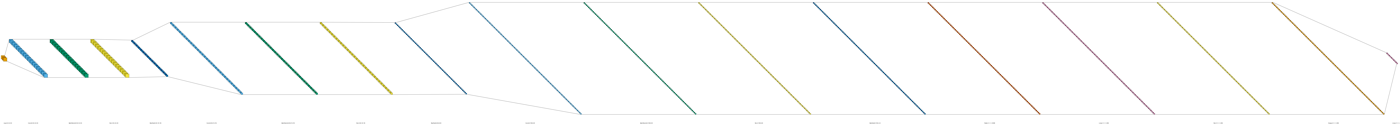

In [7]:
# LeNet-style: the "publication figure" look for SimpleCNN
img = vt.render(model_cnn, (1, 3, 32, 32), style="lenet",
                to_file=str(ASSETS / "simplecnn_lenet.png"), show_dimension=True)
show(img)


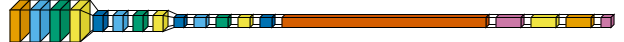

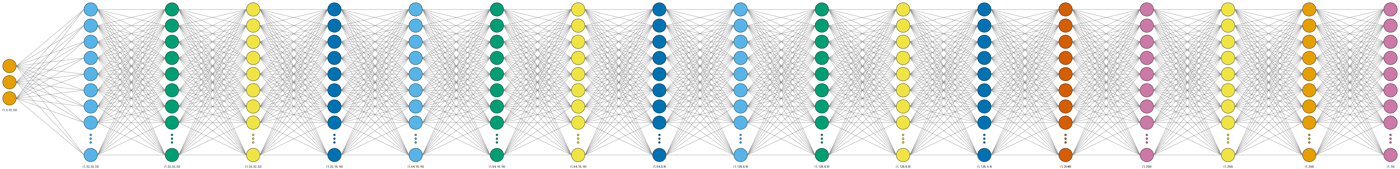

In [6]:
# Flow style (compact) and graph style (neurons as nodes) for the same model
img_flow = vt.render(model_cnn, (1, 3, 32, 32), style="flow",
                     to_file=str(ASSETS / "simplecnn_flow.png"))
show(img_flow)

img_graph = vt.render(model_cnn, (1, 3, 32, 32), style="graph",
                      to_file=str(ASSETS / "simplecnn_graph.png"), show_dimension=True)
show(img_graph)


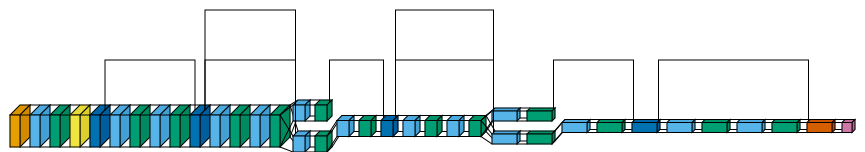

In [8]:
# SimpleResNet (Day 18): the flow view makes the *branching* (skip connections) visible —
# something a plain nn.Sequential diagram can never show.
img = vt.render(model_res, (1, 3, 32, 32), style="flow",
                to_file=str(ASSETS / "simpleresnet_flow.png"))
show(img)


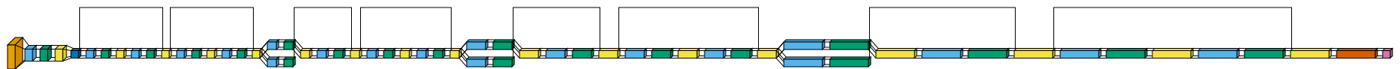

Params: 11,181,642


In [9]:
# A real architecture straight from torchvision: ResNet-18 (pretrained weights not needed).
import torchvision
r18 = torchvision.models.resnet18(num_classes=10).eval()
img = vt.render(r18, (1, 3, 32, 32), style="flow",
                to_file=str(ASSETS / "resnet18_flow.png"))
show(img)
print("Params:", f"{sum(p.numel() for p in r18.parameters()):,}")


---
## 3. Autograd execution graph — `torchviz` *(optional)*

VisualTorch draws the **modules**; `torchviz` draws the **autograd graph** — every tensor operation recorded during the forward pass, with gradients flowing backward. This is the *same* computation graph you first met on **Day 5 (Autograd)** — here we finally *see* it.

- Great for small graphs (an MLP, or the tail of a CNN).
- Gets very busy for a full CNN (hundreds of ops) — that clutter is itself instructive.
- **Requires the system Graphviz `dot` binary** → this cell is guarded.


In [ ]:
if HAS_TORCHVIZ:
    y = model_cnn(torch.randn(1, 3, 32, 32))
    dot = make_dot(y, params=dict(model_cnn.named_parameters()))
    dot.format = "png"
    dot.render(str(ASSETS / "simplecnn_torchviz"), cleanup=True)
    display(dot)
else:
    print("torchviz not installed — skipping this cell.")
    print("Install with:  brew install graphviz && .venv/bin/pip install graphviz torchviz")


---
## 4. Nested module hierarchy with shapes — `torchview` *(optional)*

`torchview` sits between the two: it draws a **module-level graph** (your `block1/block2/...`, nested) annotated with **tensor shapes**, and — unlike `torchinfo` — it shows the **connections**, including skip connections. Think "`torchinfo`'s table, as a diagram".

- `device="meta"` builds the graph **without allocating real memory** (no forward cost).
- `expand_nested=True` opens up `nn.Sequential` containers; `depth` controls how deep to unfold.
- **Requires Graphviz `dot`** → guarded.


In [10]:
if HAS_TORCHVIEW:
    g = draw_graph(model_cnn, input_size=(1, 3, 32, 32), device="meta",
                   expand_nested=True, depth=2, graph_name="SimpleCNN")
    g.visual_graph.format = "png"
    g.visual_graph.render(str(ASSETS / "simplecnn_torchview"), cleanup=True)
    display(g.visual_graph)
else:
    print("torchview not installed — skipping this cell.")
    print("Install with:  brew install graphviz && .venv/bin/pip install graphviz torchview")


NameError: name 'HAS_TORCHVIEW' is not defined

---
## 5. Interactive model-file viewer — Netron

**Netron** is the industry-standard viewer for *saved model files*. Unlike the tools above (which take a live `nn.Module`), Netron opens a **file** — ONNX, TorchScript, TensorFlow Lite, etc. — and lets you click through every node, weight tensor and shape in a browser/desktop UI.

The workflow is two steps:

1. **Export** the model to a file (here: ONNX).
2. **Open** that file in Netron.

We export the file now; opening it starts a local web server, so run it from a terminal (or uncomment the Python line) rather than baking a blocking server into the notebook.


In [11]:
# Step 1 — export SimpleCNN to ONNX
onnx_path = ASSETS / "simplecnn.onnx"
torch.onnx.export(
    model_cnn.eval(),
    torch.randn(1, 3, 32, 32),
    str(onnx_path),
    input_names=["input"], output_names=["logits"],
    opset_version=17, dynamo=False,
)
print("Exported:", onnx_path.resolve())

# Step 2 — open it. Run ONE of these outside the notebook:
print("\nOpen the interactive viewer with:")
print(f"  terminal:      .venv/bin/netron {onnx_path}")
print(f"  or in Python:  import netron; netron.start('{onnx_path}')   # serves at localhost:8080")
print("  (or drag the .onnx file onto the Netron desktop app / https://netron.app)")


Exported: /Users/pengzhao/Documents/Projects/DL_learning/day19b_network_visualization/assets/simplecnn.onnx

Open the interactive viewer with:
  terminal:      .venv/bin/netron assets/simplecnn.onnx
  or in Python:  import netron; netron.start('assets/simplecnn.onnx')   # serves at localhost:8080
  (or drag the .onnx file onto the Netron desktop app / https://netron.app)


/var/folders/w5/2bk4yy9n0jqc4g52g07kjbnc0000gn/T/ipykernel_75545/2749196505.py:3: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


---
## 6. TensorBoard graph view *(already installed — no extra deps)*

TensorBoard is already in your core `requirements.txt`. Its `add_graph` writes the model graph to a log directory that the TensorBoard web UI can display — handy because you're already using TensorBoard for loss curves.


In [12]:
from torch.utils.tensorboard import SummaryWriter

tb_dir = ASSETS / "tb"
writer = SummaryWriter(str(tb_dir))
writer.add_graph(model_cnn.eval(), torch.randn(1, 3, 32, 32))
writer.close()

print("TensorBoard graph written to:", tb_dir.resolve())
print("Launch the UI with:  .venv/bin/tensorboard --logdir", tb_dir)
print("Then open the 'GRAPHS' tab in the browser.")


TensorBoard graph written to: /Users/pengzhao/Documents/Projects/DL_learning/day19b_network_visualization/assets/tb
Launch the UI with:  .venv/bin/tensorboard --logdir assets/tb
Then open the 'GRAPHS' tab in the browser.


---
## 7. Appendix — PlotNeuralNets (LaTeX/TikZ)

The classic "3D slab" network diagram you see in papers (the [PlotNeuralNet](https://github.com/HarisIqbal88/PlotNeuralNet) look) is **not a Python package** — it is LaTeX/TikZ code that you generate and compile.

- **Pros:** beautiful, fully customizable, vector output, camera-ready.
- **Cons:** needs a LaTeX install (MacTeX, several GB); not "point at a model and go"; you hand-write the layers.

Because VisualTorch's `lenet` style already gives a very similar look with **zero system dependencies**, we default to VisualTorch. Reach for PlotNeuralNets only when you need a bespoke figure for a publication.

Minimal hand-written example (save as `net.tex`, compile with `pdflatex net.tex`):

```latex
\documentclass{standalone}
\usepackage{tikz}
\usetikzlibrary{positioning}
\begin{document}
\begin{tikzpicture}[
  layer/.style={draw, fill=blue!15, minimum height=2.2cm, minimum width=0.5cm}]
  \node[layer, minimum width=0.3cm] (in) {};
  \node[layer, right=1.2cm of in, fill=green!20] (c1) {};
  \node[layer, right=1.2cm of c1, fill=green!30] (c2) {};
  \node[layer, right=1.2cm of c2, fill=green!40] (c3) {};
  \node[layer, right=1.6cm of c3, fill=orange!30, minimum height=1.2cm] (fc) {};
  \draw[->] (in) -- (c1);
  \draw[->] (c1) -- (c2);
  \draw[->] (c2) -- (c3);
  \draw[->] (c3) -- (fc);
  \node[below=0.2cm of in] {input};
  \node[below=0.2cm of fc] {logits};
\end{tikzpicture}
\end{document}
```


---
## 8. Which tool, when?

| Tool | Axis | Input | Output | System dep? | Best for |
|---|---|---|---|---|---|
| `torchinfo` | structure | live model | text table (shapes, params) | none | exact layer facts, param counts |
| **VisualTorch** | structure | live model | PIL image (flow / graph / lenet) | none | **paper / talk figures**, skip connections |
| **Netron** | structure | model **file** (ONNX/…) | interactive UI | none | inspecting saved/exported models, weights, shapes |
| TensorBoard `add_graph` | structure | live model | web UI graph | none | alongside your training curves |
| `torchviz` | structure (autograd) | live model + forward | Graphviz diagram | **Graphviz** | seeing the autograd graph (small nets) |
| `torchview` | structure | live model | Graphviz diagram + shapes | **Graphviz** | nested module hierarchy with shapes |
| PlotNeuralNets | structure | hand-written LaTeX | PDF / TikZ | **LaTeX** | bespoke publication figures |
| *Day 19 tools* | **behavior** | trained model + data | heatmaps, histograms | none | what the network *learned* |

**Rule of thumb:** start with `torchinfo` (facts) → `VisualTorch` (the figure) → `Netron` (when you have a saved file). Add `torchviz`/`torchview` only if you want the autograd/module graph and can install Graphviz.


---
## 🧪 Exercises

1. **`torchinfo` deep-dive** — run `summary` on `SimpleResNet` and find the `num_params` of `layer2.0.shortcut`. Why is it non-empty there but empty in `layer1.0`? (Hint: Day 18 — when does a block need a *projection* shortcut?)
2. **Styles** — render `SimpleResNet` in the `lenet` style. Can you locate the skip connections?
3. **Real models** — render `torchvision.models.vgg16()` and `torchvision.models.resnet50()` in `flow` style. Which is deeper? Which has more *branches*?
4. **Netron** — export `SimpleResNet` to ONNX and open it in Netron. Find the `Add` nodes — those are `out = out + identity`, i.e. the skip connections.
5. **Your own model** — pick any model from Day 17 / Day 18 and render all three VisualTorch styles.


In [ ]:
# Exercises: your code here


---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **Structure vs behavior** | Day 19 shows *what* a CNN learned; Day 19b shows *what* it *is* |
| **`torchinfo`** | Exact layer shapes + param counts, as text — always start here |
| **VisualTorch** | Publication-quality flow / graph / lenet diagrams, **no system deps** |
| **Netron** | Industry-standard interactive viewer for *saved model files* |
| **TensorBoard** | Graph view you already have installed |
| **torchviz / torchview** | Autograd graph / nested module graph (need Graphviz) |
| **Skip connections need a graph** | Only branching-aware tools (VisualTorch, torchview, Netron) show ResNet skips — a plain `nn.Sequential` diagram cannot |

**Cross-links:**
- **Day 5** — the autograd computation graph you now *draw* with `torchviz`.
- **Day 17** — `SimpleCNN`'s `block1/2/3` structure these diagrams expose.
- **Day 18** — `SimpleResNet`'s skip connections, visible only in a *graph*.
- **Day 19** — the behavior-side companion (filters, feature maps, CAM).
- **Day 20** — you'll render `resnet18` again, this time to see what transfer learning *reuses*.
- **Days 25–26** — VisualTorch and the visualization habits reappear for the ViT.

**Install reminder:** `.venv/bin/pip install -r requirements-viz.txt`; optional Graphviz tools via `brew install graphviz`.
